In [2]:
import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("../../data/weatherData.csv")

In [4]:
df.head()

,location_id,date,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),apparent_temperature_max (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),daylight_duration (s),...,precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm),sunrise,sunset
0,0,1/1/2010,1,30.1,22.6,26.0,34.5,25.0,29.0,42220.20,...,0.0,0.0,0,12.2,27.4,19,20.92,4.61,06:22,18:05
1,0,1/2/2010,51,30.1,23.7,26.3,33.9,26.1,29.7,42225.71,...,0.1,0.1,1,13.0,27.0,24,17.71,3.91,06:22,18:06
2,0,1/3/2010,51,29.6,23.1,26.0,34.5,26.2,29.9,42231.68,...,0.6,0.6,3,12.3,27.4,17,17.76,3.66,06:22,18:06
3,0,1/4/2010,2,28.9,23.1,25.7,31.7,26.1,28.4,42238.11,...,0.0,0.0,0,17.0,34.6,357,16.50,3.75,06:23,18:07
4,0,1/5/2010,1,28.1,21.3,24.6,30.0,22.9,26.2,42244.99,...,0.0,0.0,0,18.7,37.1,353,23.61,5.00,06:23,18:07


In [5]:
df.columns

Index(['location_id', 'date', 'weather_code (wmo code)',
       'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'temperature_2m_mean (°C)', 'apparent_temperature_max (°C)',
       'apparent_temperature_min (°C)', 'apparent_temperature_mean (°C)',
       'daylight_duration (s)', 'sunshine_duration (s)',
       'precipitation_sum (mm)', 'rain_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_max (km/h)', 'wind_gusts_10m_max (km/h)',
       'wind_direction_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)',
       'et0_fao_evapotranspiration (mm)', 'sunrise', 'sunset'],
      dtype='object')

In [6]:
# Parse date (coerce invalids), drop invalid dates and duplicates
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']).drop_duplicates().reset_index(drop=True)

In [7]:
df['date']

0        2010-01-01
1        2010-01-02
2        2010-01-03
3        2010-01-04
4        2010-01-05
            ...    
142366   2024-06-04
142367   2024-06-05
142368   2024-06-06
142369   2024-06-07
142370   2024-06-08
Name: date, Length: 142371, dtype: datetime64[ns]

In [8]:
# Rename columns for consistency
rename_map = {
    'temperature_2m_mean (°C)': 'temp_mean',
    'precipitation_sum (mm)': 'precip_sum',
    'rain_sum (mm)': 'rain_sum',
    'wind_speed_10m_max (km/h)': 'wind_speed_max',
    'weather_code (wmo code)': 'weather_code'
}
df = df.rename(columns=rename_map)

In [9]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temperature_2m_max (°C)',
       'temperature_2m_min (°C)', 'temp_mean', 'apparent_temperature_max (°C)',
       'apparent_temperature_min (°C)', 'apparent_temperature_mean (°C)',
       'daylight_duration (s)', 'sunshine_duration (s)', 'precip_sum',
       'rain_sum', 'precipitation_hours (h)', 'wind_speed_max',
       'wind_gusts_10m_max (km/h)', 'wind_direction_10m_dominant (°)',
       'shortwave_radiation_sum (MJ/m²)', 'et0_fao_evapotranspiration (mm)',
       'sunrise', 'sunset'],
      dtype='object')

In [10]:
# -------------------- 2️⃣ Date Features --------------------
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

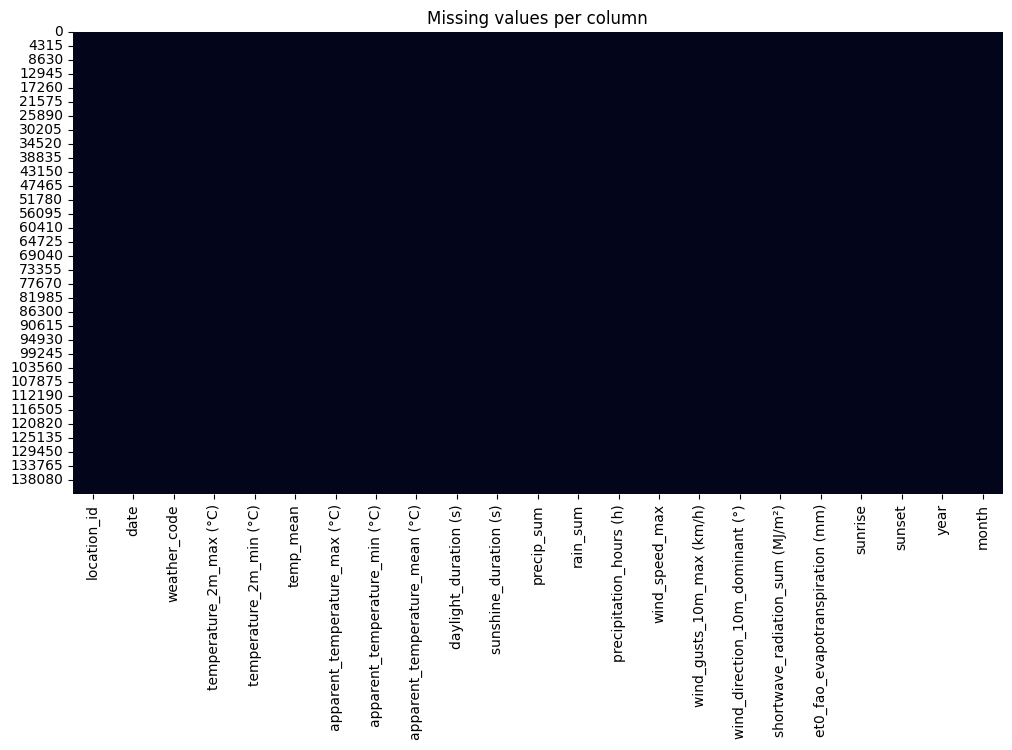

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing values per column")
plt.show()

In [12]:
# there are no missing values in the dataset

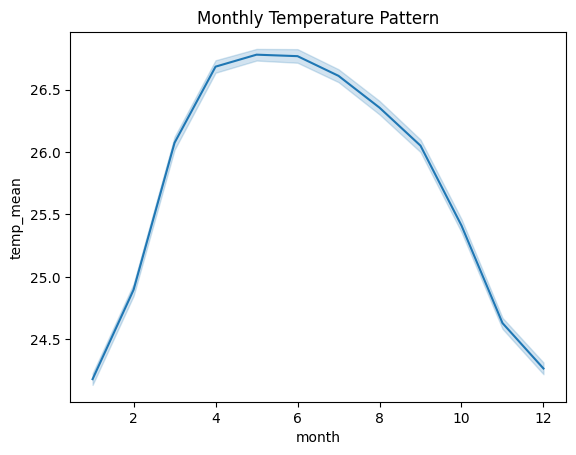

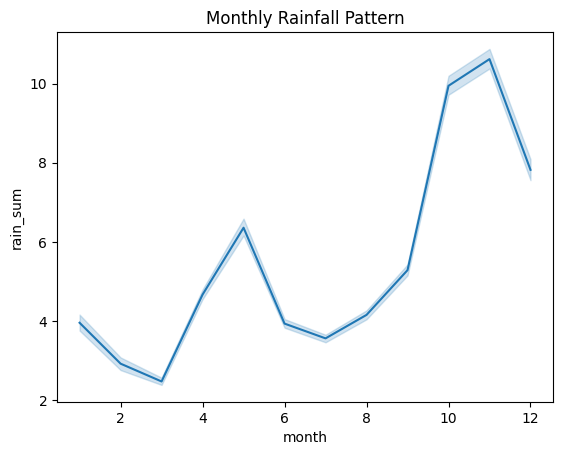

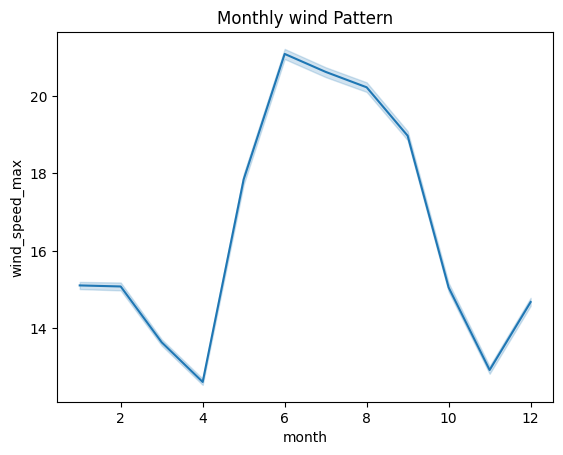

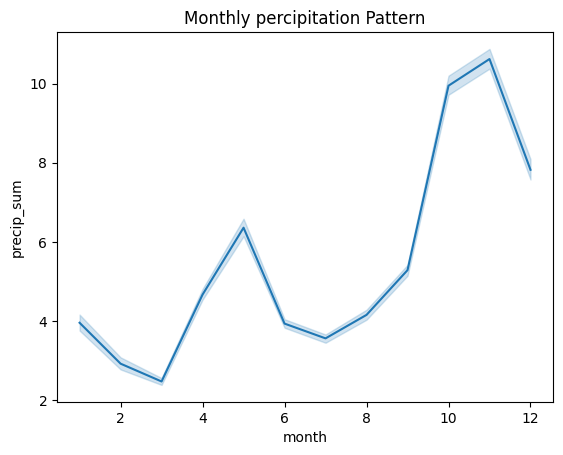

In [13]:
sns.lineplot(x="month", y="temp_mean", data=df)
plt.title("Monthly Temperature Pattern")
plt.show()

sns.lineplot(x="month", y="rain_sum", data=df)
plt.title("Monthly Rainfall Pattern")
plt.show()

sns.lineplot(x="month", y="wind_speed_max", data=df)
plt.title("Monthly wind Pattern")
plt.show()

sns.lineplot(x="month", y="precip_sum", data=df)
plt.title("Monthly percipitation Pattern")
plt.show()


In [14]:
df.columns.tolist()

['location_id',
 'date',
 'weather_code',
 'temperature_2m_max (°C)',
 'temperature_2m_min (°C)',
 'temp_mean',
 'apparent_temperature_max (°C)',
 'apparent_temperature_min (°C)',
 'apparent_temperature_mean (°C)',
 'daylight_duration (s)',
 'sunshine_duration (s)',
 'precip_sum',
 'rain_sum',
 'precipitation_hours (h)',
 'wind_speed_max',
 'wind_gusts_10m_max (km/h)',
 'wind_direction_10m_dominant (°)',
 'shortwave_radiation_sum (MJ/m²)',
 'et0_fao_evapotranspiration (mm)',
 'sunrise',
 'sunset',
 'year',
 'month']

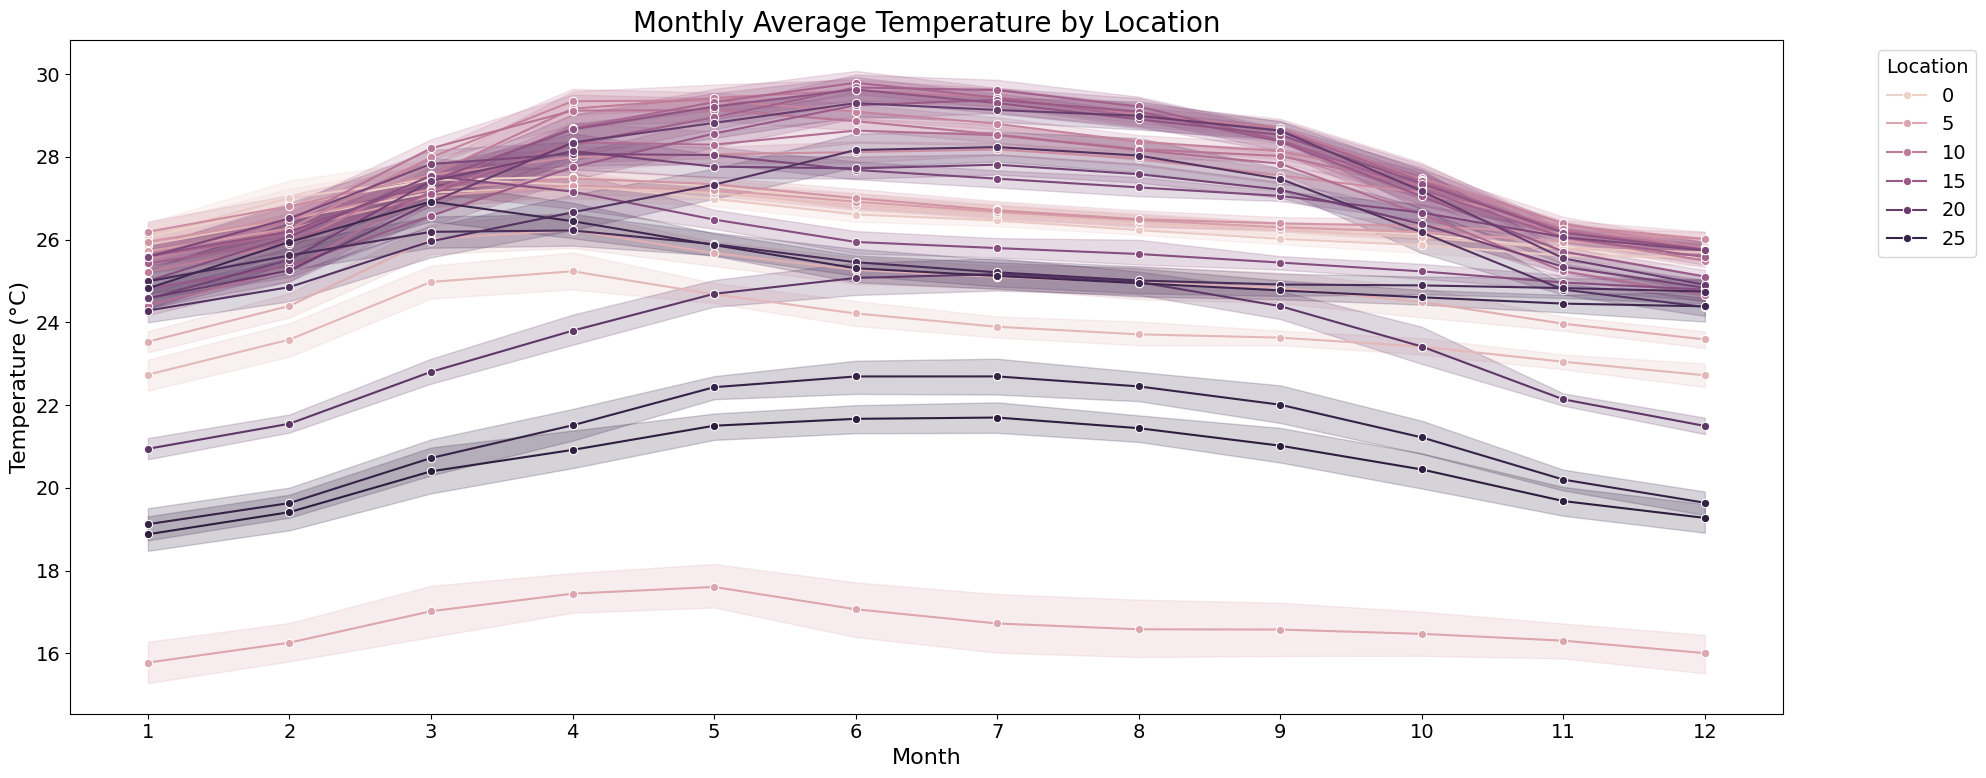

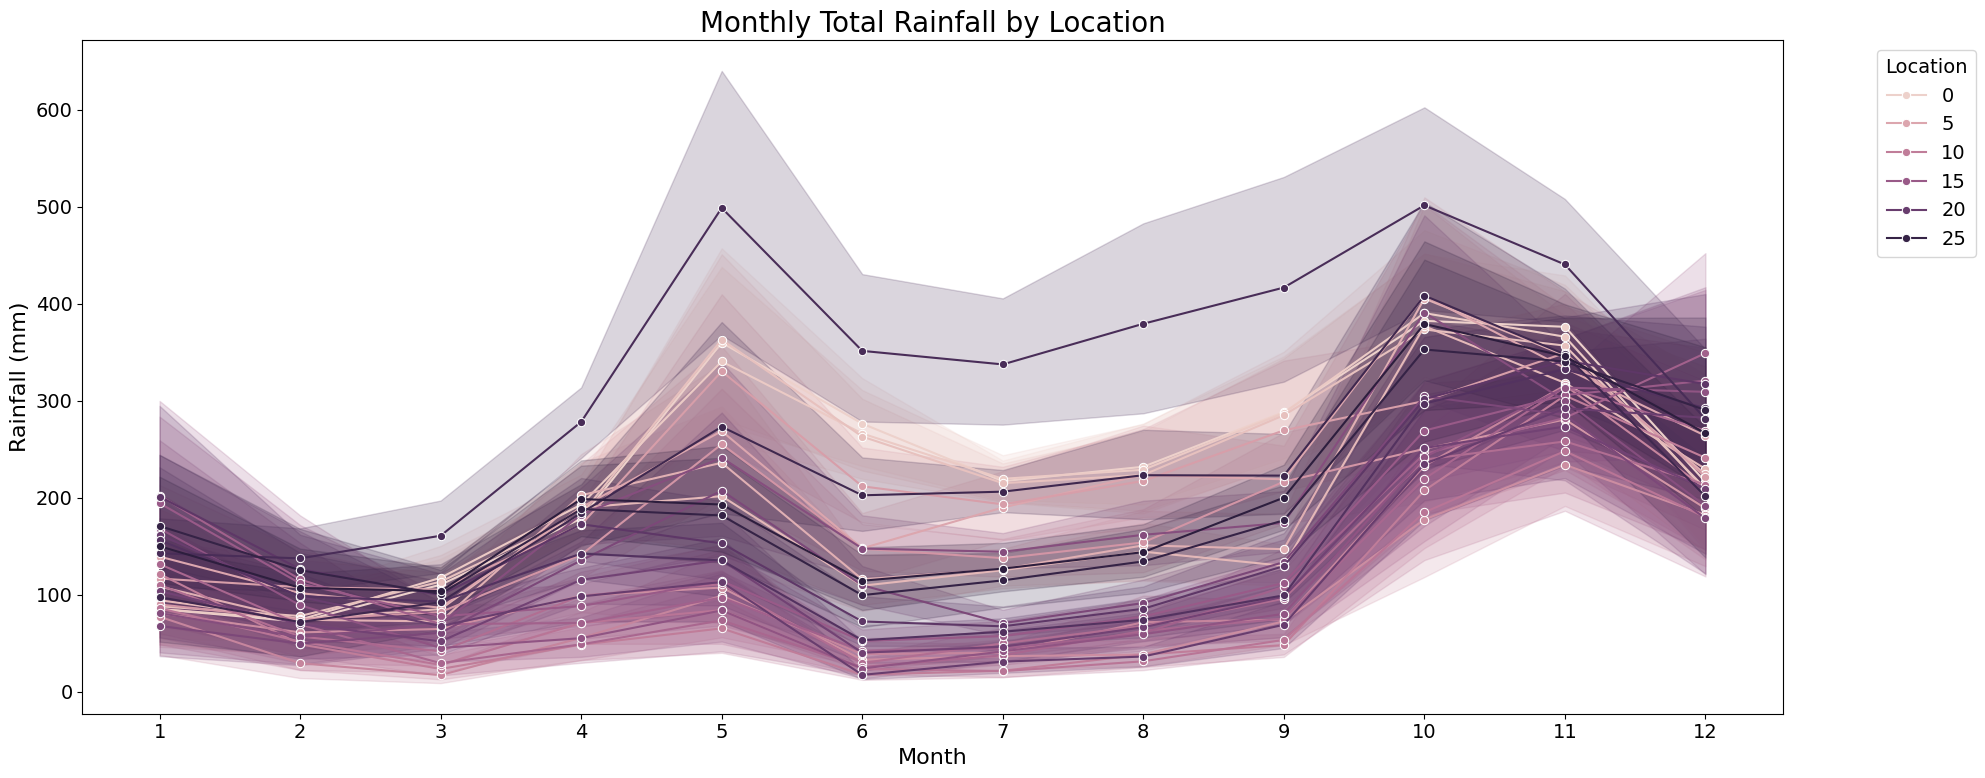

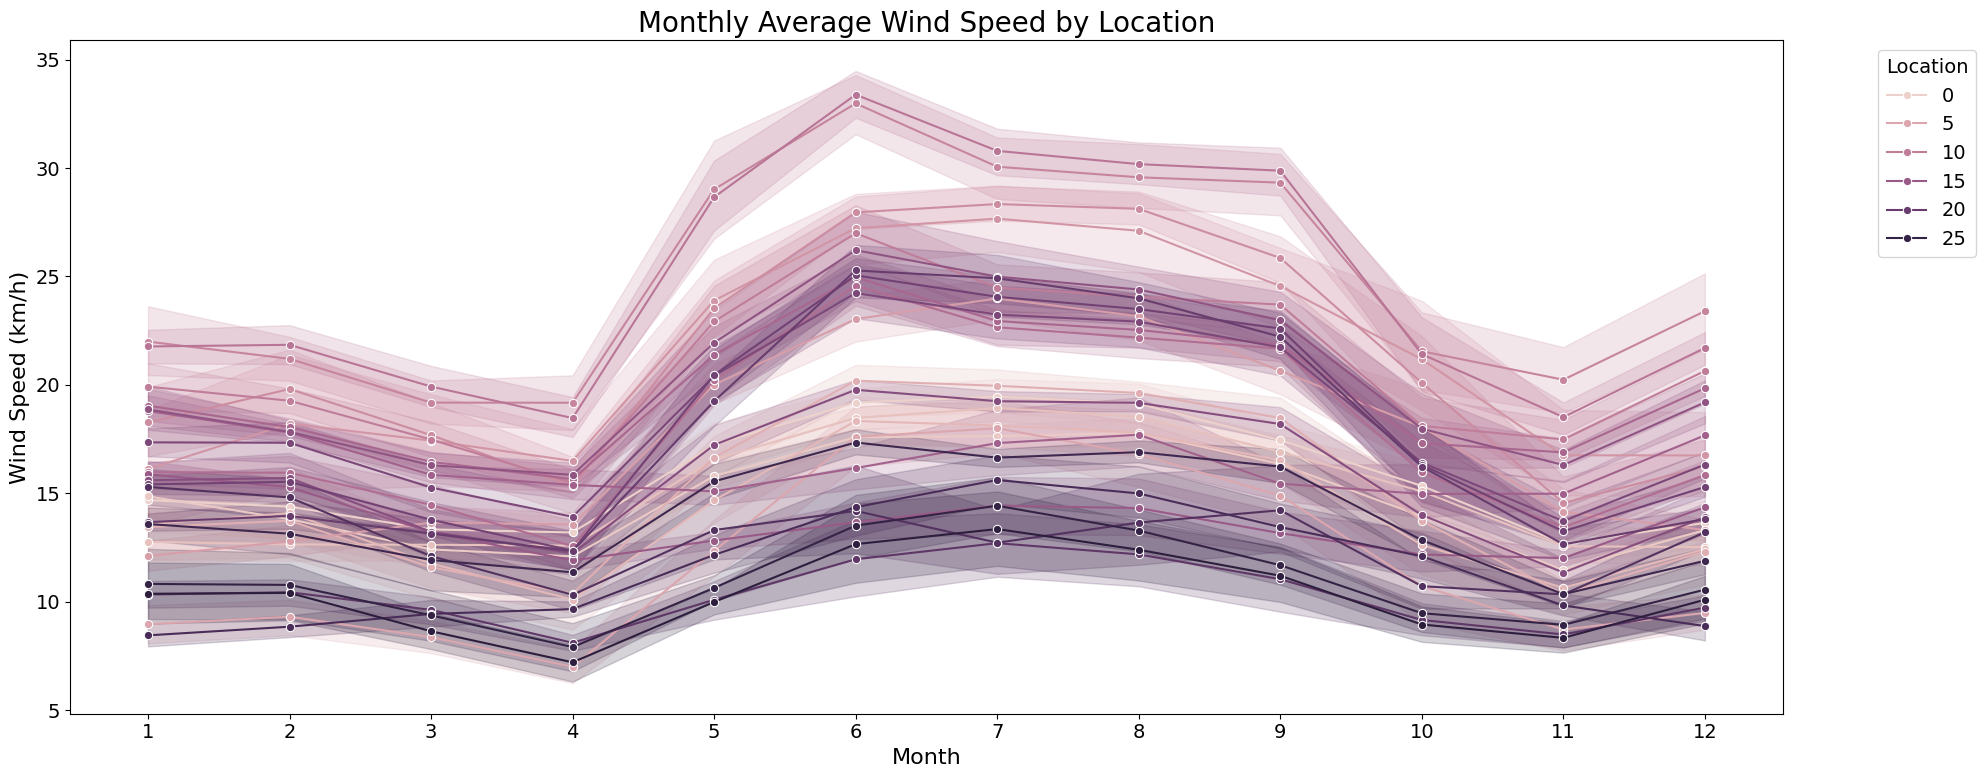

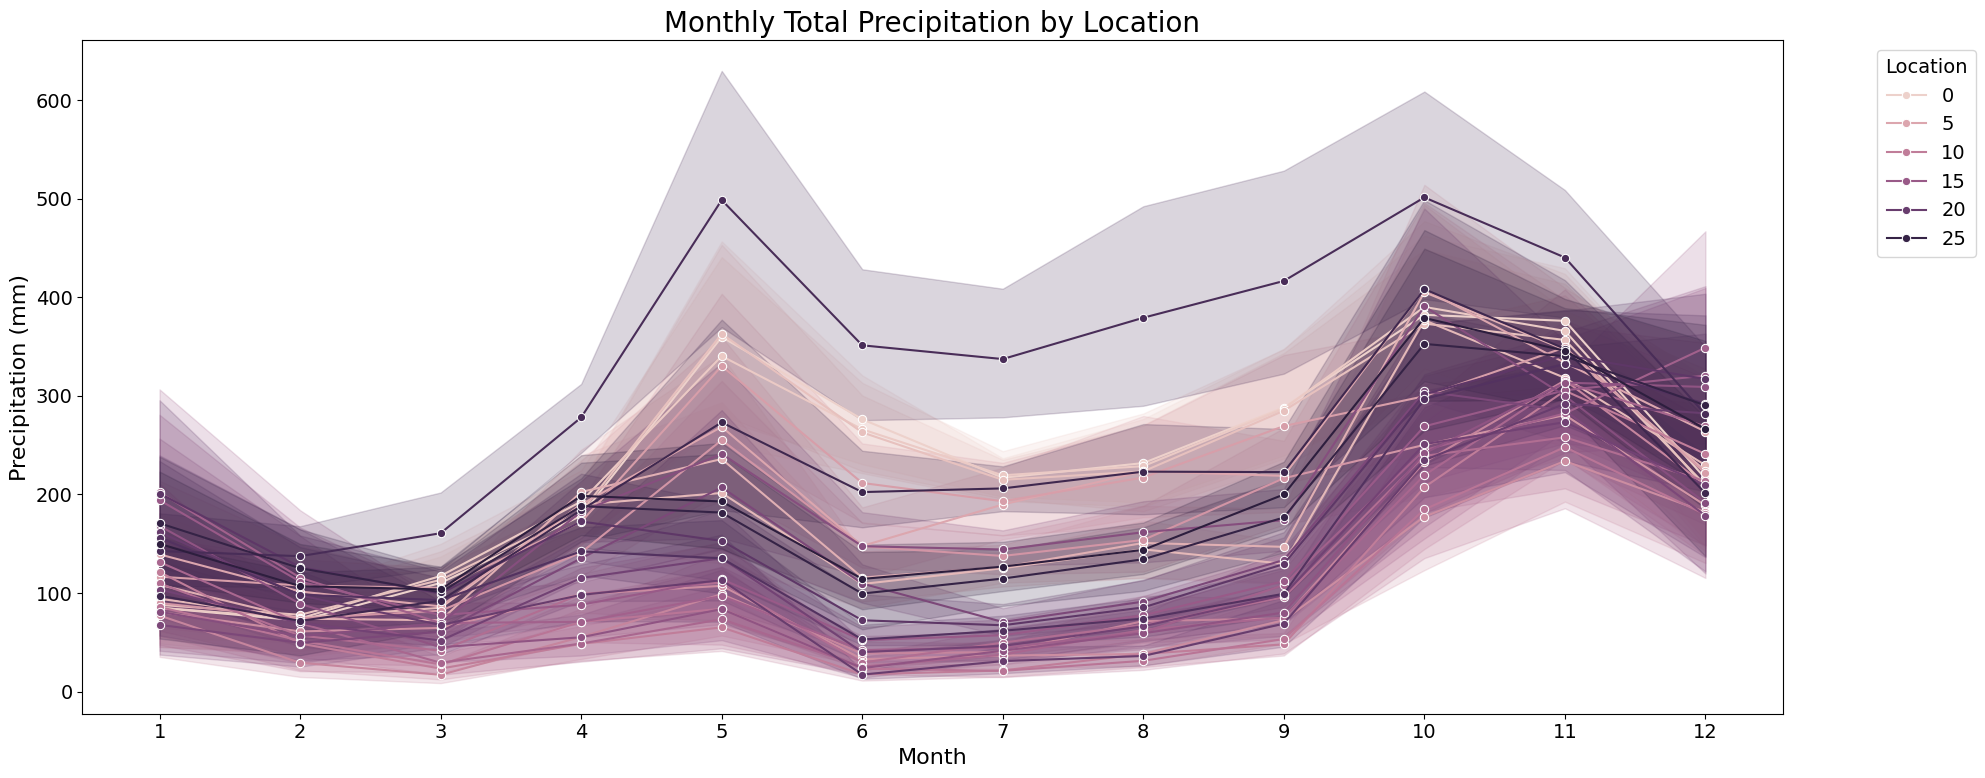

In [15]:
monthly_location_year = df.groupby(['location_id', 'year', 'month']).agg({
    'temp_mean': 'mean',
    'rain_sum': 'sum',
    'wind_speed_max': 'mean',
    'precip_sum': 'sum'
}).reset_index()

# Optional: rename for clarity (already mostly clear)
monthly_location_year.rename(columns={
    'temp_mean': 'temp_mean',
    'rain_sum': 'rain_sum',
    'wind_speed_max': 'wind_speed_max',
    'precip_sum': 'precip_sum'
}, inplace=True)
# Bigger figure and font settings
plt.rcParams.update({'font.size': 14})

# Temperature
plt.figure(figsize=(20, 8))  # bigger width & height
sns.lineplot(
    x='month', 
    y='temp_mean', 
    hue='location_id', 
    data=monthly_location_year, 
    marker='o'
)
plt.title("Monthly Average Temperature by Location", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Temperature (°C)", fontsize=16)
plt.xticks(range(1, 13))
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Rainfall
plt.figure(figsize=(20, 8))
sns.lineplot(
    x='month', 
    y='rain_sum', 
    hue='location_id', 
    data=monthly_location_year, 
    marker='o'
)
plt.title("Monthly Total Rainfall by Location", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Rainfall (mm)", fontsize=16)
plt.xticks(range(1, 13))
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Wind Speed
plt.figure(figsize=(20, 8))
sns.lineplot(
    x='month', 
    y='wind_speed_max', 
    hue='location_id', 
    data=monthly_location_year, 
    marker='o'
)
plt.title("Monthly Average Wind Speed by Location", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Wind Speed (km/h)", fontsize=16)
plt.xticks(range(1, 13))
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Precipitation
plt.figure(figsize=(20, 8))
sns.lineplot(
    x='month', 
    y='precip_sum', 
    hue='location_id', 
    data=monthly_location_year, 
    marker='o'
)
plt.title("Monthly Total Precipitation by Location", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Precipitation (mm)", fontsize=16)
plt.xticks(range(1, 13))
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [16]:
numeric_cols = df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()
print(corr_matrix)

                                  location_id  weather_code  \
location_id                      1.000000e+00     -0.020001   
weather_code                    -2.000090e-02      1.000000   
temperature_2m_max (°C)          1.354173e-02     -0.240042   
temperature_2m_min (°C)         -2.012979e-01     -0.016407   
temp_mean                       -1.222578e-01     -0.161914   
apparent_temperature_max (°C)   -1.645424e-02     -0.074746   
apparent_temperature_min (°C)   -2.025316e-01      0.069722   
apparent_temperature_mean (°C)  -1.367046e-01     -0.007782   
daylight_duration (s)            2.617107e-04      0.042173   
sunshine_duration (s)           -1.711347e-02     -0.336387   
precip_sum                      -7.098242e-03      0.388749   
rain_sum                        -7.098242e-03      0.388749   
precipitation_hours (h)         -9.898134e-02      0.632714   
wind_speed_max                  -1.938643e-01     -0.175762   
wind_gusts_10m_max (km/h)       -1.235682e-01     -0.05

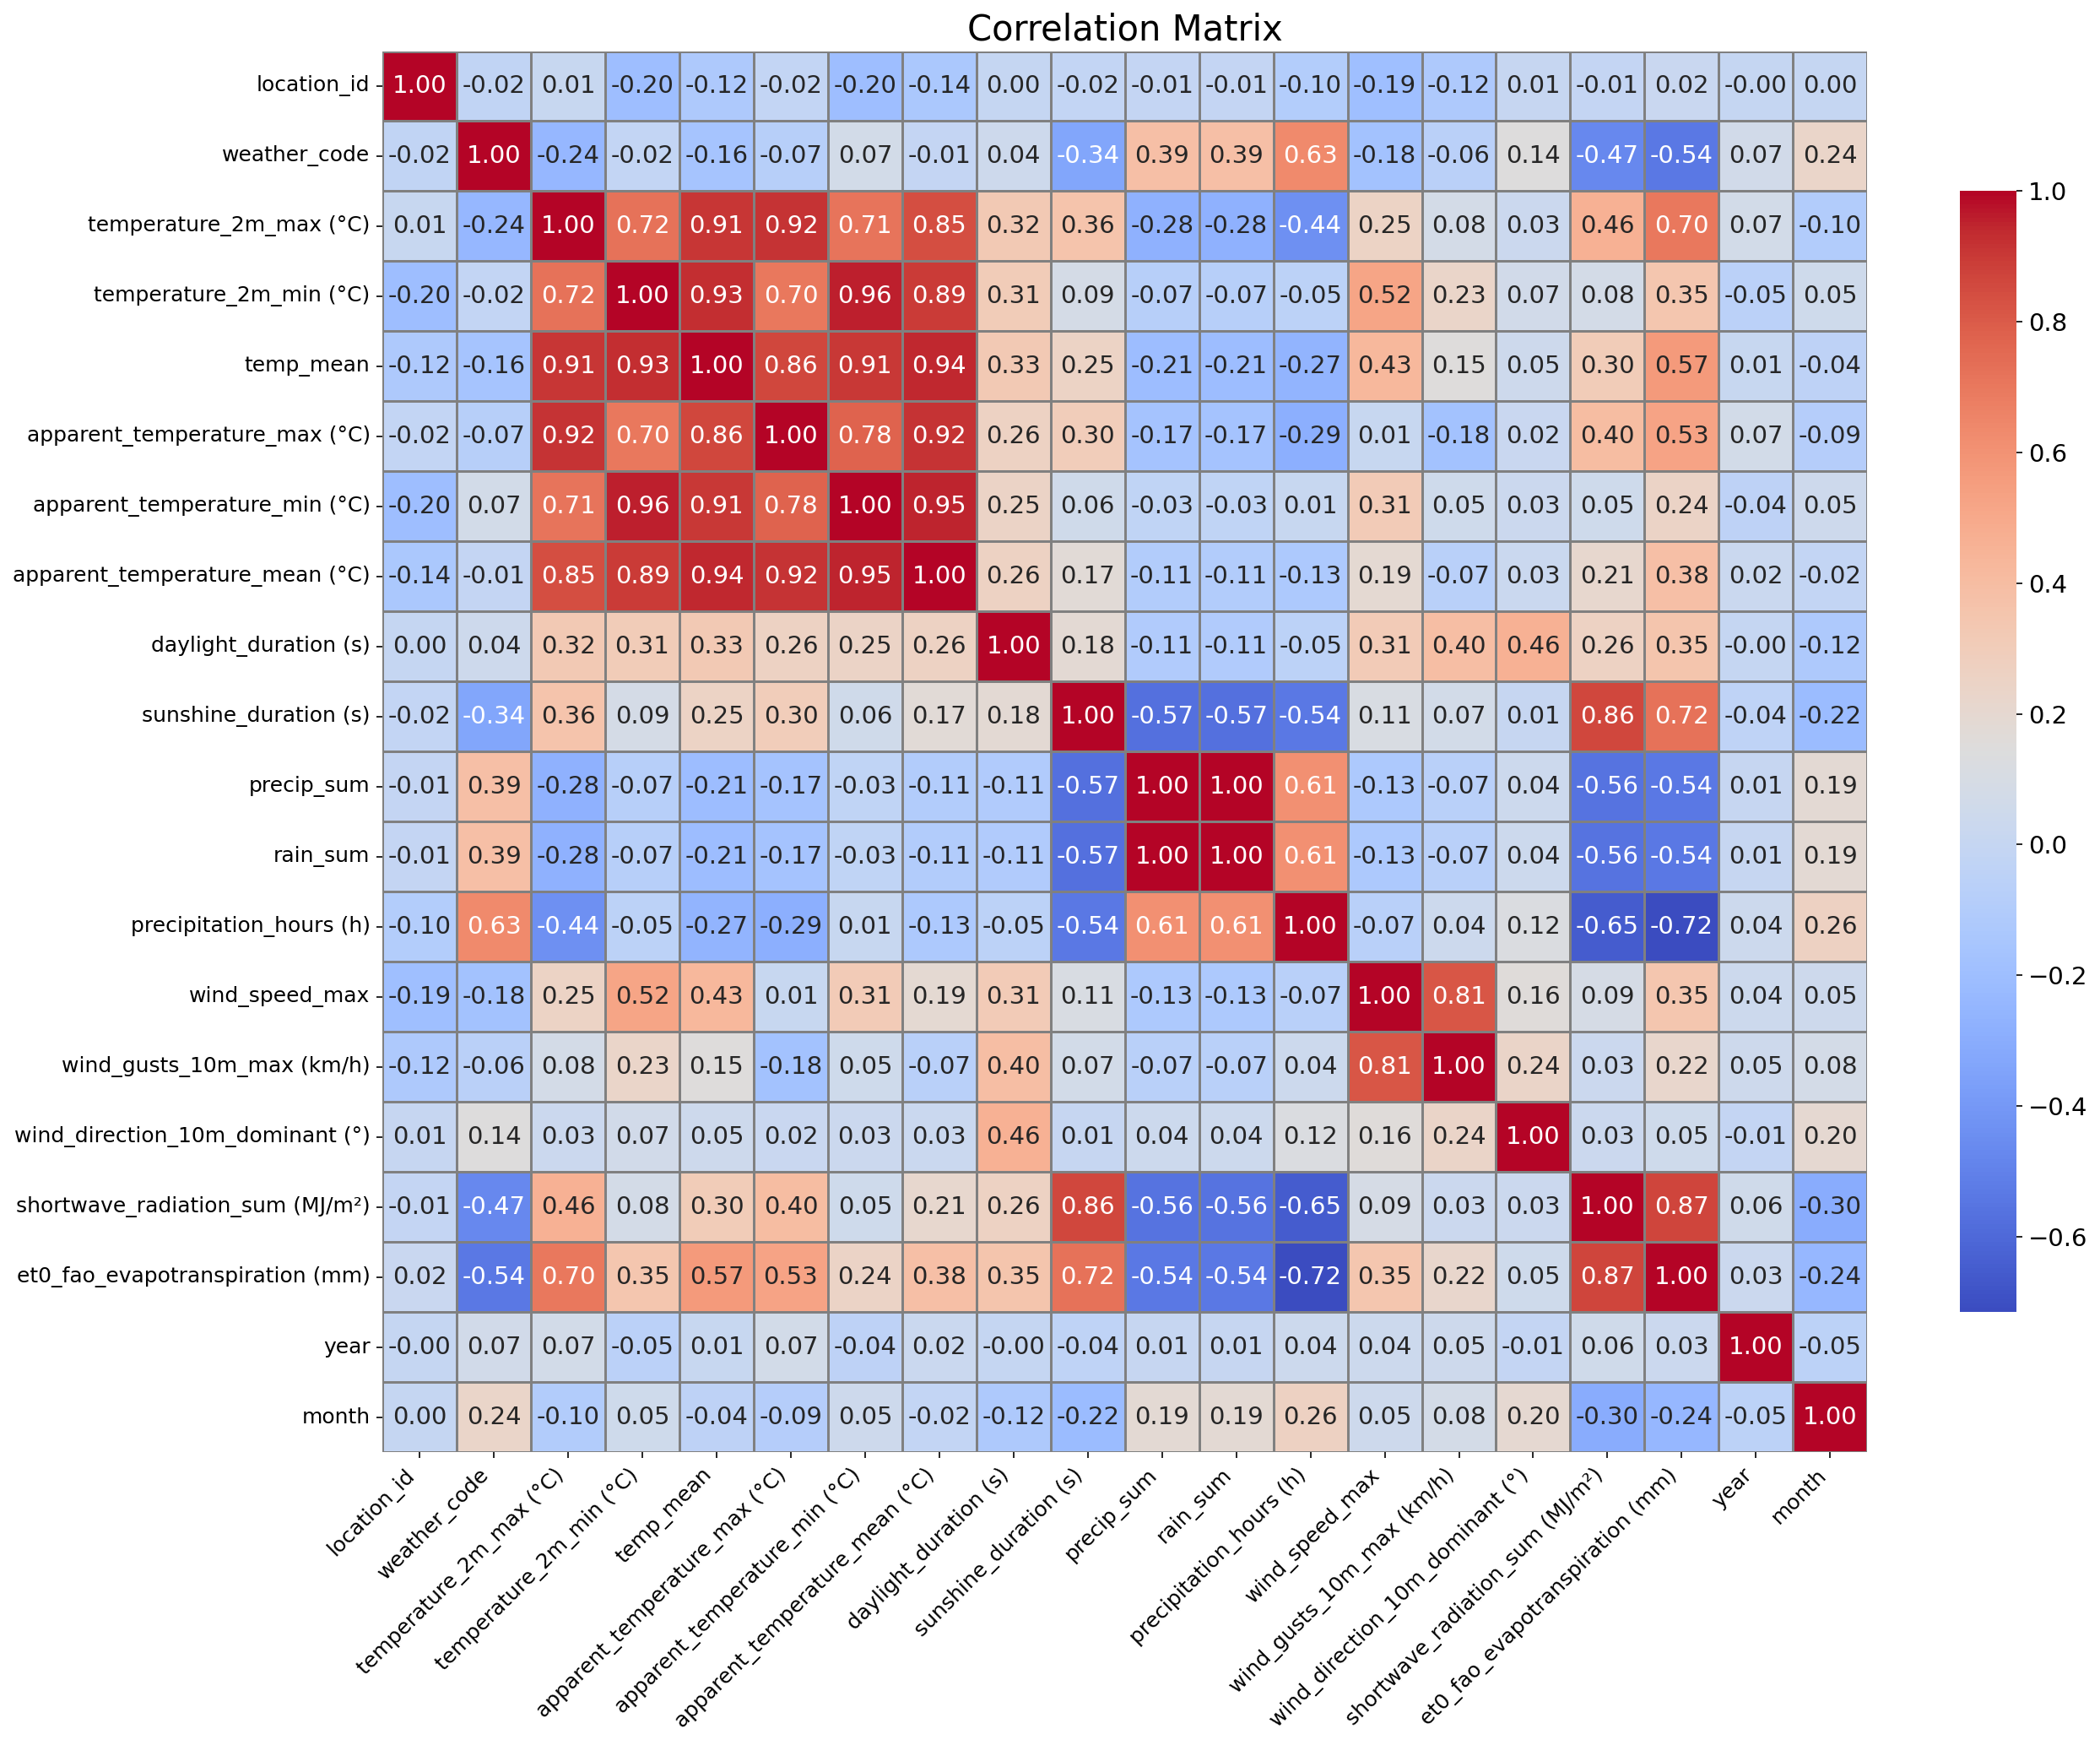

In [17]:
plt.figure(figsize=(18, 14), dpi=150)  # bigger figure + higher resolution
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            linewidths=0.5, linecolor='gray', cbar_kws={'shrink':0.8})
plt.title("Correlation Matrix", fontsize=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


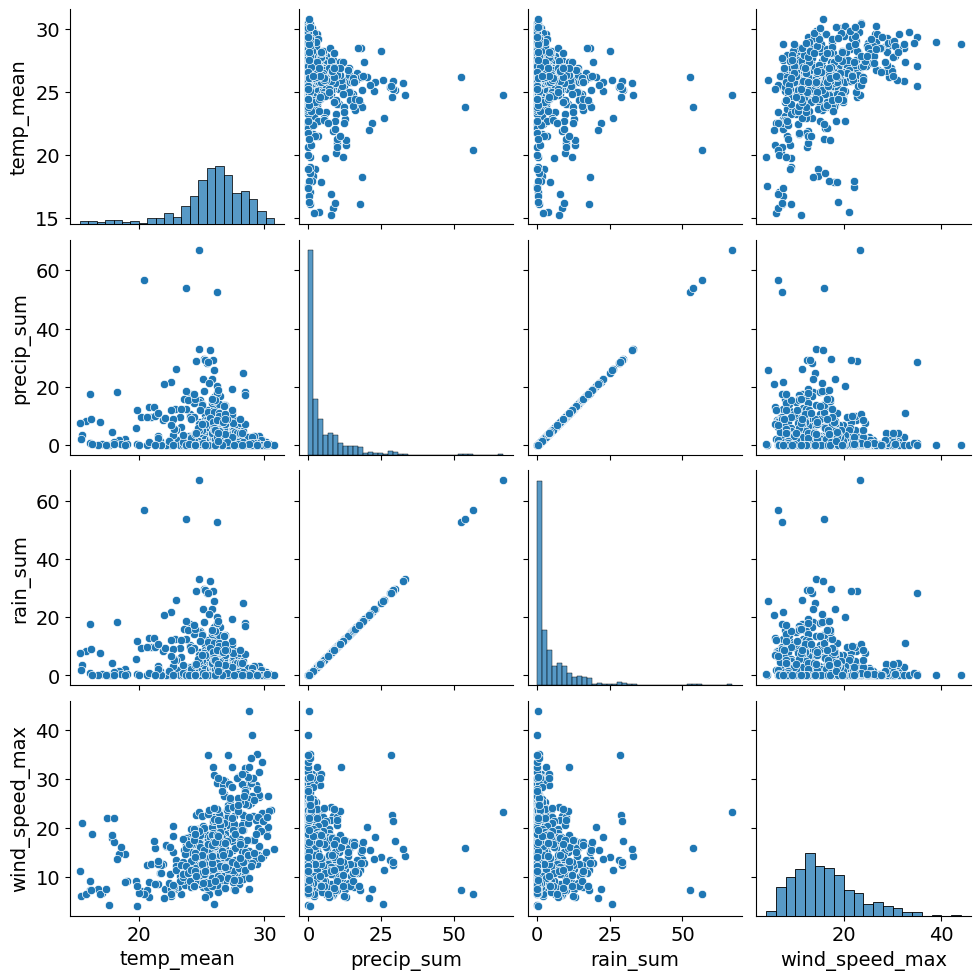

In [18]:
sample_df = df[['temp_mean', 'precip_sum', 'rain_sum', 'wind_speed_max']].sample(500, random_state=42)

sns.pairplot(sample_df)
plt.show()

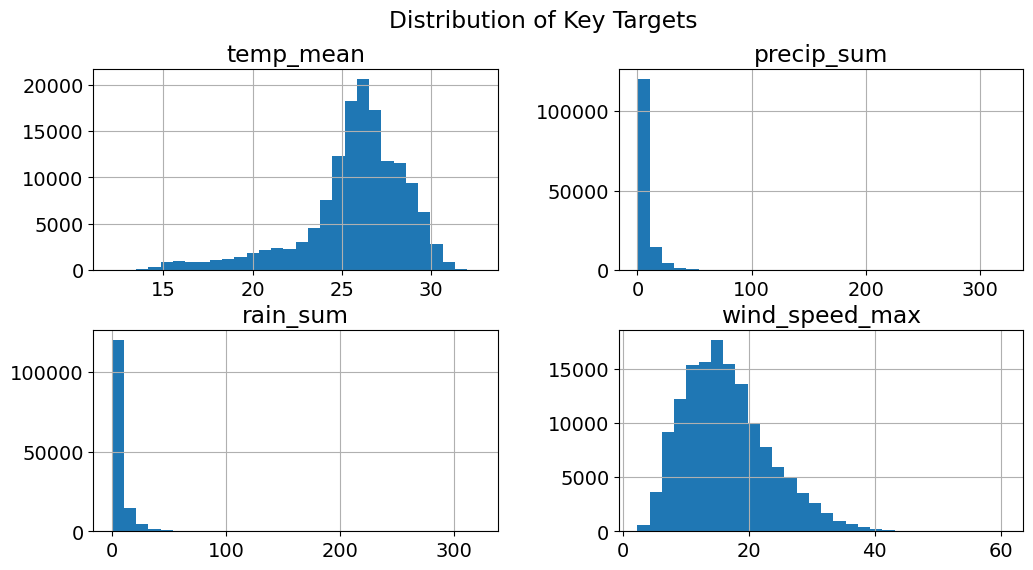

In [19]:
df[['temp_mean', 'precip_sum', 'rain_sum', 'wind_speed_max']].hist(bins=30, figsize=(12,6))
plt.suptitle("Distribution of Key Targets")
plt.show()

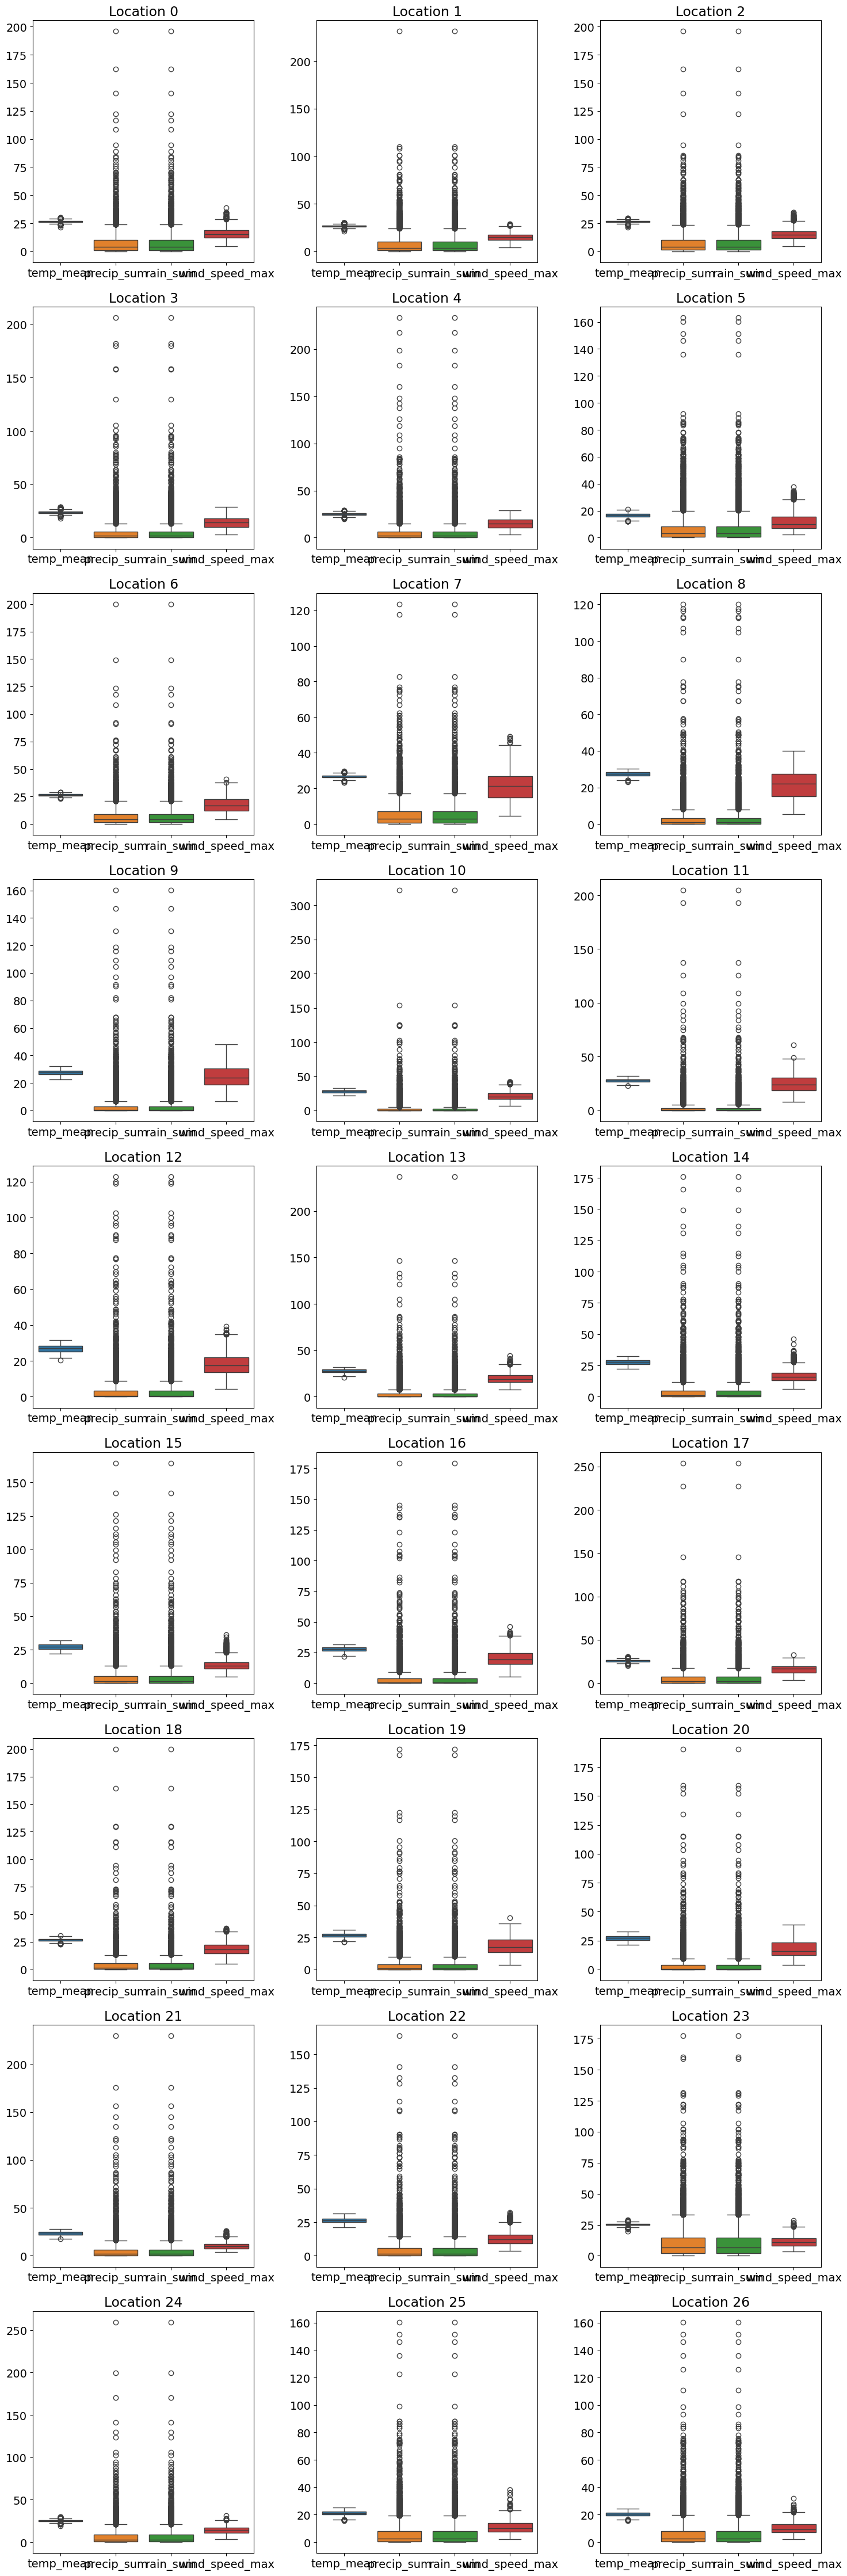

In [20]:
variables = ['temp_mean', 'precip_sum', 'rain_sum', 'wind_speed_max']
locations = df['location_id'].unique()
n_locations = len(locations)

# Define grid size for subplots
n_cols = 3  # you can adjust
n_rows = int(np.ceil(n_locations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
axes = axes.flatten()

for i, loc in enumerate(locations):
    city_df = df[df['location_id'] == loc]
    sns.boxplot(data=city_df[variables], ax=axes[i])
    axes[i].set_title(f'Location {loc}')

# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("all_locations_outliers_boxplot.png")
plt.show()

In [21]:
df.head(10)

,location_id,date,weather_code,temperature_2m_max (°C),temperature_2m_min (°C),temp_mean,apparent_temperature_max (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),daylight_duration (s),...,precipitation_hours (h),wind_speed_max,wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm),sunrise,sunset,year,month
0,0,2010-01-01,1,30.1,22.6,26.0,34.5,25.0,29.0,42220.20,...,0,12.2,27.4,19,20.92,4.61,06:22,18:05,2010,1
1,0,2010-01-02,51,30.1,23.7,26.3,33.9,26.1,29.7,42225.71,...,1,13.0,27.0,24,17.71,3.91,06:22,18:06,2010,1
2,0,2010-01-03,51,29.6,23.1,26.0,34.5,26.2,29.9,42231.68,...,3,12.3,27.4,17,17.76,3.66,06:22,18:06,2010,1
3,0,2010-01-04,2,28.9,23.1,25.7,31.7,26.1,28.4,42238.11,...,0,17.0,34.6,357,16.50,3.75,06:23,18:07,2010,1
4,0,2010-01-05,1,28.1,21.3,24.6,30.0,22.9,26.2,42244.99,...,0,18.7,37.1,353,23.61,5.00,06:23,18:07,2010,1
5,0,2010-01-06,1,28.8,21.3,24.9,31.2,22.8,26.3,42252.32,...,0,17.1,32.0,12,21.48,4.95,06:23,18:08,2010,1
6,0,2010-01-07,3,29.3,22.0,25.6,34.0,24.2,28.3,42260.19,...,0,13.5,25.6,10,19.38,4.38,06:24,18:08,2010,1
7,0,2010-01-08,53,28.4,23.4,25.6,32.2,26.1,29.0,42268.61,...,3,13.0,24.8,7,13.00,2.98,06:24,18:09,2010,1
8,0,2010-01-09,61,29.1,23.5,26.0,35.4,28.3,31.3,42277.55,...,5,11.5,31.7,163,16.89,3.34,06:24,18:09,2010,1
9,0,2010-01-10,51,30.1,22.6,26.2,35.8,27.1,31.2,42287.01,...,1,6.9,18.4,101,20.52,4.15,06:25,18:10,2010,1


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142371 entries, 0 to 142370
Data columns (total 23 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   location_id                      142371 non-null  int64         
 1   date                             142371 non-null  datetime64[ns]
 2   weather_code                     142371 non-null  int64         
 3   temperature_2m_max (°C)          142371 non-null  float64       
 4   temperature_2m_min (°C)          142371 non-null  float64       
 5   temp_mean                        142371 non-null  float64       
 6   apparent_temperature_max (°C)    142371 non-null  float64       
 7   apparent_temperature_min (°C)    142371 non-null  float64       
 8   apparent_temperature_mean (°C)   142371 non-null  float64       
 9   daylight_duration (s)            142371 non-null  float64       
 10  sunshine_duration (s)            142371 non-

In [23]:
df.describe()

,location_id,date,weather_code,temperature_2m_max (°C),temperature_2m_min (°C),temp_mean,apparent_temperature_max (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),daylight_duration (s),...,precip_sum,rain_sum,precipitation_hours (h),wind_speed_max,wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm),year,month
count,142371.000000,142371,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,...,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000
mean,13.000000,2017-03-21 00:00:00,44.891586,29.295854,23.120601,25.730017,33.560477,26.362139,29.234477,43645.975220,...,5.442717,5.442717,7.337955,16.461730,37.118828,177.723567,18.933608,4.115296,2016.727290,6.421202
min,0.000000,2010-01-01 00:00:00,0.000000,14.100000,5.300000,12.100000,11.000000,2.000000,9.500000,41610.710000,...,0.000000,0.000000,0.000000,2.300000,9.400000,0.000000,1.120000,0.380000,2010.000000,1.000000
25%,6.000000,2013-08-11 00:00:00,51.000000,27.700000,22.000000,24.700000,31.400000,25.100000,27.900000,42607.350000,...,0.200000,0.200000,1.000000,11.400000,28.100000,78.000000,16.570000,3.350000,2013.000000,3.000000
50%,13.000000,2017-03-21 00:00:00,53.000000,29.300000,23.800000,26.200000,33.900000,27.600000,30.100000,43648.880000,...,1.800000,1.800000,6.000000,15.600000,35.300000,209.000000,19.710000,4.110000,2017.000000,6.000000
75%,20.000000,2020-10-29 00:00:00,61.000000,31.300000,25.200000,27.600000,36.300000,29.100000,31.600000,44685.075000,...,6.500000,6.500000,12.000000,20.400000,44.300000,247.000000,22.090000,4.890000,2020.000000,9.000000
max,26.000000,2024-06-08 00:00:00,65.000000,40.300000,30.300000,32.700000,46.100000,35.600000,37.700000,45676.100000,...,321.800000,321.800000,24.000000,60.700000,123.500000,360.000000,29.400000,8.450000,2024.000000,12.000000
std,7.788908,NaN,22.840879,3.352774,3.165760,2.954064,4.183799,4.196010,3.837440,1099.470021,...,10.286371,10.286371,6.861958,6.828743,11.676963,95.393165,4.398970,1.179600,4.172428,3.454946


In [24]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temperature_2m_max (°C)',
       'temperature_2m_min (°C)', 'temp_mean', 'apparent_temperature_max (°C)',
       'apparent_temperature_min (°C)', 'apparent_temperature_mean (°C)',
       'daylight_duration (s)', 'sunshine_duration (s)', 'precip_sum',
       'rain_sum', 'precipitation_hours (h)', 'wind_speed_max',
       'wind_gusts_10m_max (km/h)', 'wind_direction_10m_dominant (°)',
       'shortwave_radiation_sum (MJ/m²)', 'et0_fao_evapotranspiration (mm)',
       'sunrise', 'sunset', 'year', 'month'],
      dtype='object')

In [25]:
# Drop unwanted columns
drop_cols = [
    'precipitation_hours (h)',"daylight_duration (s)",
    'wind_gusts_10m_max (km/h)',
    'wind_direction_10m_dominant (°)',
    'shortwave_radiation_sum (MJ/m²)',
    'et0_fao_evapotranspiration (mm)',
    'sunrise', 'sunset',
    'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
    'apparent_temperature_max (°C)', 'apparent_temperature_min (°C)',
    'apparent_temperature_mean (°C)', 'sunshine_duration (s)'
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors='ignore')

In [26]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temp_mean', 'precip_sum',
       'rain_sum', 'wind_speed_max', 'year', 'month'],
      dtype='object')

In [27]:
df.head()

,location_id,date,weather_code,temp_mean,precip_sum,rain_sum,wind_speed_max,year,month
0,0,2010-01-01,1,26.0,0.0,0.0,12.2,2010,1
1,0,2010-01-02,51,26.3,0.1,0.1,13.0,2010,1
2,0,2010-01-03,51,26.0,0.6,0.6,12.3,2010,1
3,0,2010-01-04,2,25.7,0.0,0.0,17.0,2010,1
4,0,2010-01-05,1,24.6,0.0,0.0,18.7,2010,1


In [28]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temp_mean', 'precip_sum',
       'rain_sum', 'wind_speed_max', 'year', 'month'],
      dtype='object')

# feature engineering

In [29]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofyear'] = df['date'].dt.dayofyear
df['weekday'] = df['date'].dt.weekday  # Monday=0

# Cyclic encoding for day of year
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

In [30]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temp_mean', 'precip_sum',
       'rain_sum', 'wind_speed_max', 'year', 'month', 'day', 'dayofyear',
       'weekday', 'dayofyear_sin', 'dayofyear_cos'],
      dtype='object')

In [31]:
# Historical Aggregates
# Compute historical mean for each target per location + dayofyear
targets = ['temp_mean', 'rain_sum', 'precip_sum', 'wind_speed_max']

for target in targets:
    hist = df.groupby(['location_id', 'dayofyear'])[target].mean().reset_index()
    hist.rename(columns={target: f'{target}_hist'}, inplace=True)
    df = df.merge(hist, on=['location_id', 'dayofyear'], how='left')

In [32]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temp_mean', 'precip_sum',
       'rain_sum', 'wind_speed_max', 'year', 'month', 'day', 'dayofyear',
       'weekday', 'dayofyear_sin', 'dayofyear_cos', 'temp_mean_hist',
       'rain_sum_hist', 'precip_sum_hist', 'wind_speed_max_hist'],
      dtype='object')

In [33]:
# Features & Targets --------------------
features = [
    'location_id', 'weather_code', 'month', 'weekday',
    'dayofyear_sin', 'dayofyear_cos',
    'temp_mean_hist', 'rain_sum_hist', 'precip_sum_hist', 'wind_speed_max_hist'
]
cat_features = ['location_id', 'weather_code']
y_targets = ['rain_sum', 'precip_sum', 'temp_mean', 'wind_speed_max']

In [34]:
X = df[features]
y = df[y_targets]

In [35]:
X.columns

Index(['location_id', 'weather_code', 'month', 'weekday', 'dayofyear_sin',
       'dayofyear_cos', 'temp_mean_hist', 'rain_sum_hist', 'precip_sum_hist',
       'wind_speed_max_hist'],
      dtype='object')

In [36]:
y

,rain_sum,precip_sum,temp_mean,wind_speed_max
0,0.0,0.0,26.0,12.2
1,0.1,0.1,26.3,13.0
2,0.6,0.6,26.0,12.3
3,0.0,0.0,25.7,17.0
4,0.0,0.0,24.6,18.7
...,...,...,...,...
142366,1.7,1.7,21.2,11.3
142367,1.4,1.4,21.1,13.1
142368,1.8,1.8,20.4,10.9
142369,4.3,4.3,20.9,11.9


In [37]:
df.head()

,location_id,date,weather_code,temp_mean,precip_sum,rain_sum,wind_speed_max,year,month,day,dayofyear,weekday,dayofyear_sin,dayofyear_cos,temp_mean_hist,rain_sum_hist,precip_sum_hist,wind_speed_max_hist
0,0,2010-01-01,1,26.0,0.0,0.0,12.2,2010,1,1,1,4,0.017213,0.999852,25.873333,2.180000,2.180000,13.480000
1,0,2010-01-02,51,26.3,0.1,0.1,13.0,2010,1,2,2,5,0.034422,0.999407,25.920000,3.060000,3.060000,14.473333
2,0,2010-01-03,51,26.0,0.6,0.6,12.3,2010,1,3,3,6,0.051620,0.998667,26.046667,2.680000,2.680000,15.226667
3,0,2010-01-04,2,25.7,0.0,0.0,17.0,2010,1,4,4,0,0.068802,0.997630,25.893333,1.826667,1.826667,15.713333
4,0,2010-01-05,1,24.6,0.0,0.0,18.7,2010,1,5,5,1,0.085965,0.996298,25.693333,2.926667,2.926667,16.060000


In [38]:
#  Train / Validation / Test Split (time series)
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [39]:
# Create CatBoost Pools
train_pool = Pool(X_train, label=y_train, cat_features=cat_features)
val_pool   = Pool(X_val, label=y_val, cat_features=cat_features)
test_pool  = Pool(X_test, label=y_test, cat_features=cat_features)

In [40]:
X_train.shape

(99659, 10)

In [41]:
X_test.shape

(21356, 10)

In [42]:
X_val.shape

(21356, 10)

In [43]:
# 6. Train CatBoost model
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function='MultiRMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

In [44]:
model.fit(train_pool, eval_set=val_pool, use_best_model=True)

0:	learn: 15.4939720	test: 15.3520747	best: 15.3520747 (0)	total: 263ms	remaining: 8m 44s
100:	learn: 8.7997099	test: 8.7047146	best: 8.7047146 (100)	total: 14.9s	remaining: 4m 39s
200:	learn: 8.5079401	test: 8.5246238	best: 8.5246238 (200)	total: 31.5s	remaining: 4m 42s
300:	learn: 8.3482846	test: 8.4407855	best: 8.4407855 (300)	total: 45.3s	remaining: 4m 15s
400:	learn: 8.2322915	test: 8.4057739	best: 8.4057739 (400)	total: 59s	remaining: 3m 55s
500:	learn: 8.1165036	test: 8.3904113	best: 8.3821845 (459)	total: 1m 13s	remaining: 3m 38s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.382184503
bestIteration = 459

Shrink model to first 460 iterations.


In [46]:
# Predicted values for location 5 on 2026-01-01:
# rain_sum: 0.28
# precip_sum: 0.28
# temp_mean: 15.88
# wind_speed_max: 9.19

# Evaluate Model

In [47]:
def evaluate(model, pool, y_true, dataset_name="Test"):
    y_pred = model.predict(pool)
    print(f"\n{dataset_name} Performance")
    for i, col in enumerate(y_true.columns):
        mse = mean_squared_error(y_true[col], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true[col], y_pred[:, i])
        r2 = r2_score(y_true[col], y_pred[:, i])
        print(f"{col} → RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}")
    return y_pred

In [48]:
# Validate
y_val_pred = evaluate(model, val_pool, y_val, "Validation")


Validation Performance
rain_sum → RMSE: 5.212, MAE: 2.086, R2: 0.720
precip_sum → RMSE: 5.212, MAE: 2.086, R2: 0.720
temp_mean → RMSE: 1.060, MAE: 0.828, R2: 0.796
wind_speed_max → RMSE: 3.848, MAE: 3.042, R2: 0.637


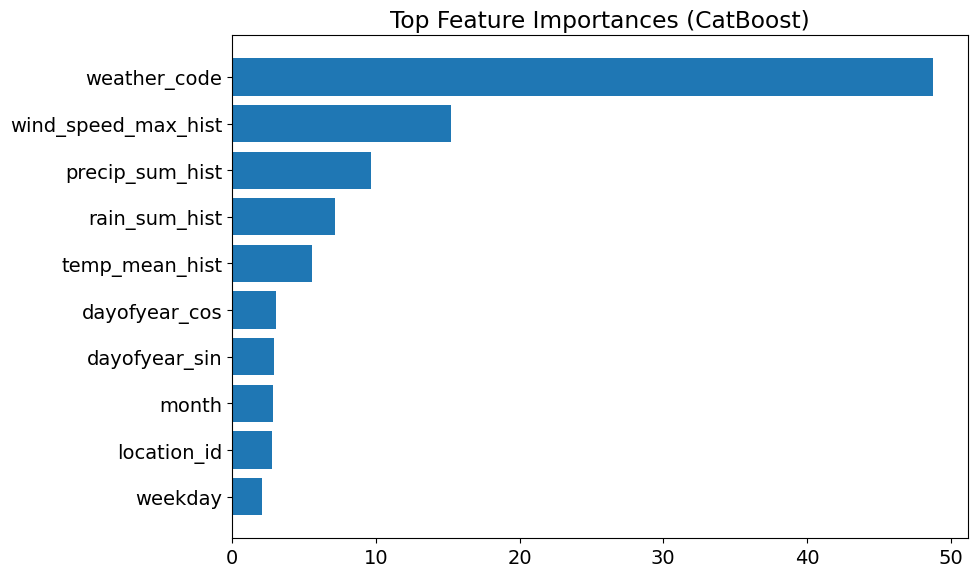

In [49]:
# Feature importance
importances = model.get_feature_importance(train_pool)
feat_imp = pd.DataFrame({"feature": features, "importance": importances})
feat_imp = feat_imp.sort_values(by="importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (CatBoost)")
plt.tight_layout()
plt.show()

# Hyperparameter tuning

In [50]:
# Hyperparameter tuning can be done using GridSearchCV for better performance.

In [51]:
# 6. Hyperparameter tuning
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'iterations': [1000]
}

In [52]:
tuner = CatBoostRegressor(
    loss_function='MultiRMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=False
)

In [53]:
# grid_search uses the Pool object
grid_result = tuner.grid_search(param_grid, train_pool, cv=3, partition_random_seed=42, verbose=False)
print("\nBest Parameters from grid_search:", grid_result['params'])

# Train best model and evaluate on test

best_model = CatBoostRegressor(
    **grid_result['params'],
    loss_function='MultiRMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

best_model.fit(train_pool, eval_set=val_pool, use_best_model=True)


bestTest = 9.22129341
bestIteration = 997

Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.897936217
bestIteration = 925

Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.97673726
bestIteration = 329


bestTest = 9.234528458
bestIteration = 999


bestTest = 8.869710818
bestIteration = 999

Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.854581991
bestIteration = 634


bestTest = 9.242923365
bestIteration = 999


bestTest = 8.912988819
bestIteration = 999

Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.855269208
bestIteration = 797


bestTest = 8.904216609
bestIteration = 999

Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.689453428
bestIteration = 523

Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.775994718
bestIteration = 263


bestTest = 8.951339628
bestIteration = 999

Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.723666295
bestIteration =

In [54]:
# Validation
_ = evaluate(best_model, val_pool, y_val, "Validation")


Validation Performance


rain_sum → RMSE: 5.188, MAE: 2.056, R2: 0.723
precip_sum → RMSE: 5.188, MAE: 2.056, R2: 0.723
temp_mean → RMSE: 0.936, MAE: 0.737, R2: 0.841
wind_speed_max → RMSE: 3.800, MAE: 2.987, R2: 0.646


In [55]:
# Test
_ = evaluate(best_model, test_pool, y_test, "Test")


Test Performance
rain_sum → RMSE: 6.800, MAE: 3.204, R2: 0.662
precip_sum → RMSE: 6.800, MAE: 3.204, R2: 0.662
temp_mean → RMSE: 1.237, MAE: 0.972, R2: 0.776
wind_speed_max → RMSE: 3.496, MAE: 2.820, R2: 0.378


In [59]:

os.makedirs("../../models", exist_ok=True)
tuned_model_path_cbm = "../../models/catboost_weather.cbm"
best_model.save_model(tuned_model_path_cbm)

print(f"Trained tuned model saved to: {tuned_model_path_cbm}")


Trained tuned model saved to: ../../models/catboost_weather.cbm


In [57]:
def predict_future(location_id, date, df, model, features, cat_features):
    date = pd.to_datetime(date)
    dayofyear = date.timetuple().tm_yday
    weekday = date.weekday()
    # Most frequent weather code
    weather_code = df[(df['location_id'] == location_id) & 
                      (df['dayofyear'] == dayofyear)]['weather_code'].mode()[0]
    
    future_row = pd.DataFrame([{
        'location_id': location_id,
        'weather_code': weather_code,
        'month': date.month,
        'weekday': weekday,
        'dayofyear_sin': np.sin(2 * np.pi * dayofyear / 365),
        'dayofyear_cos': np.cos(2 * np.pi * dayofyear / 365),
    }])
    
    # Add historical averages
    for target in ['temp_mean', 'rain_sum', 'precip_sum', 'wind_speed_max']:
        hist_value = df[(df['location_id'] == location_id) & (df['dayofyear'] == dayofyear)][f'{target}_hist'].mean()
        future_row[f'{target}_hist'] = hist_value
    
    future_row = future_row[features]
    for cat in cat_features:
        future_row[cat] = future_row[cat].astype('category')
    
    pool = Pool(future_row, cat_features=cat_features)
    prediction = model.predict(pool)
    
    return dict(zip(y_targets, prediction[0]))

# Example: Predict for location 5 on 2026-01-01
pred = predict_future(5, "2026-01-01", df, best_model, features, cat_features)
print("\nPrediction for location 5 on 2026-01-01:", pred)


Prediction for location 5 on 2026-01-01: {'rain_sum': np.float64(3.076899397202216), 'precip_sum': np.float64(3.076899397202216), 'temp_mean': np.float64(15.797920350122851), 'wind_speed_max': np.float64(9.40072677849819)}
